# 🎬 Netflix Titles — Exploratory Data Analysis

**Goal:** Clean and analyze the Netflix Titles dataset to uncover patterns in genres, countries, ratings, and release/addition trends, and communicate the findings through clear visualizations.

**Dataset:** [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows) — 8,807 titles listed on Netflix as of 2021, including cast, director, country, release year, rating, duration, and genre information.

**Workflow:**
1. Load & inspect the raw data
2. Clean missing values and fix data types
3. Engineer useful features (year added, primary country, genre list, duration split)
4. Explore & visualize: content type, growth over time, countries, genres, ratings, release years, duration, seasonality
5. Summarize key insights

---


## 1. Load & Inspect the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# Styling
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.4})

NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#221f1f"
PALETTE = ["#E50914", "#B81D24", "#F5F5F1", "#221f1f", "#831010", "#E87461", "#F5C6AA", "#564d4d"]
sns.set_palette(sns.color_palette(PALETTE))

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

In [2]:
df = pd.read_csv("netflix_titles.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 8807 rows, 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## 2. Missing Value Audit

Before cleaning, let's quantify exactly how much data is missing in each column, so cleaning decisions are based on evidence rather than guesswork.

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_df

,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


**Observations:**
- `director` is missing for ~30% of titles, and `cast` for ~9% — common for documentaries and reality shows, so these are filled with `"Unknown"` rather than dropped.
- `country` is missing for ~9% of titles — also filled with `"Unknown"` to preserve the rows for genre/rating/type analysis.
- `date_added` and `rating` are missing for a negligible number of rows (<0.2%) — these rows are dropped since the missing values can't be reliably imputed.

## 3. Data Cleaning

In [5]:
df_clean = df.copy()

# Fill categorical unknowns instead of dropping (preserves data for genre/country/rating analysis)
for col in ["director", "cast", "country"]:
    df_clean[col] = df_clean[col].fillna("Unknown")

# Drop the small number of rows missing rating or date_added (can't be reasonably imputed)
df_clean = df_clean.dropna(subset=["rating", "date_added"])

# Standardize whitespace in date_added, then parse to datetime
df_clean["date_added"] = df_clean["date_added"].str.strip()
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"], format="mixed")

# Drop exact duplicate titles+directors if any
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["title", "director", "country"])
print(f"Dropped {before - len(df_clean)} duplicate rows")

print(f"Rows before cleaning: {len(df)}  |  Rows after cleaning: {len(df_clean)}")

Dropped 0 duplicate rows
Rows before cleaning: 8807  |  Rows after cleaning: 8793


## 4. Feature Engineering

A few derived columns make the dataset much easier to analyze and visualize.

In [6]:
# Feature engineering
df_clean["year_added"] = df_clean["date_added"].dt.year
df_clean["month_added"] = df_clean["date_added"].dt.month_name()

# Primary (first-listed) country, useful when a title lists multiple co-production countries
df_clean["primary_country"] = df_clean["country"].apply(lambda x: x.split(",")[0].strip())

# Split duration into numeric value + unit (Movies -> minutes, TV Shows -> seasons)
df_clean["duration_int"] = df_clean["duration"].str.extract(r"(\d+)").astype(float)
df_clean["duration_unit"] = df_clean["duration"].str.extract(r"([a-zA-Z]+)")

# Explode genres (listed_in) into individual genre rows for genre-level analysis
df_clean["genre_list"] = df_clean["listed_in"].apply(lambda x: [g.strip() for g in x.split(",")])

print("New columns added: year_added, month_added, primary_country, duration_int, duration_unit, genre_list")
df_clean[["title", "year_added", "primary_country", "duration_int", "duration_unit"]].head()

New columns added: year_added, month_added, primary_country, duration_int, duration_unit, genre_list


,title,year_added,primary_country,duration_int,duration_unit
0,Dick Johnson Is Dead,2021,United States,90.0,min
1,Blood & Water,2021,South Africa,2.0,Seasons
2,Ganglands,2021,Unknown,1.0,Season
3,Jailbirds New Orleans,2021,Unknown,1.0,Season
4,Kota Factory,2021,India,2.0,Seasons


## 5. Save the Cleaned Dataset

Exporting a clean CSV means downstream analysis (or a BI tool like Tableau/Power BI) can build directly on this output.

In [7]:
df_clean.to_csv("netflix_titles_cleaned.csv", index=False)
print("Cleaned dataset saved -> netflix_titles_cleaned.csv")
print(f"Final shape: {df_clean.shape}")

Cleaned dataset saved -> netflix_titles_cleaned.csv
Final shape: (8793, 18)


---
## 6. Exploratory Data Analysis & Visualizations

### 6.1 Content Type: Movies vs. TV Shows

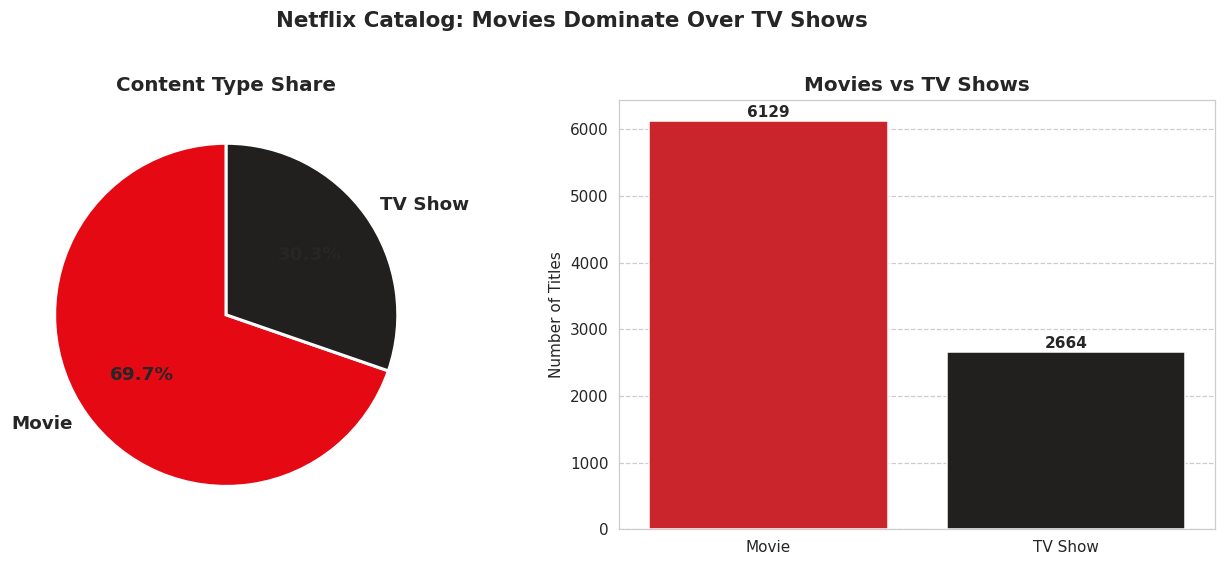

In [8]:
type_counts = df_clean["type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=[NETFLIX_RED, NETFLIX_DARK], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title("Content Type Share", fontsize=13, fontweight='bold')

sns.barplot(x=type_counts.index, y=type_counts.values, ax=axes[1],
            palette=[NETFLIX_RED, NETFLIX_DARK])
axes[1].set_title("Movies vs TV Shows", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Number of Titles")
axes[1].set_xlabel("")
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 60, str(v), ha='center', fontweight='bold')

plt.suptitle("Netflix Catalog: Movies Dominate Over TV Shows", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figs/01_content_type.png", dpi=130, bbox_inches='tight')
plt.show()

> **Insight:** Movies make up roughly 70% of the Netflix catalog, with TV Shows the remaining 30% — Netflix's library still leans heavily toward films despite its reputation for binge-worthy series.

### 6.2 Catalog Growth Over Time

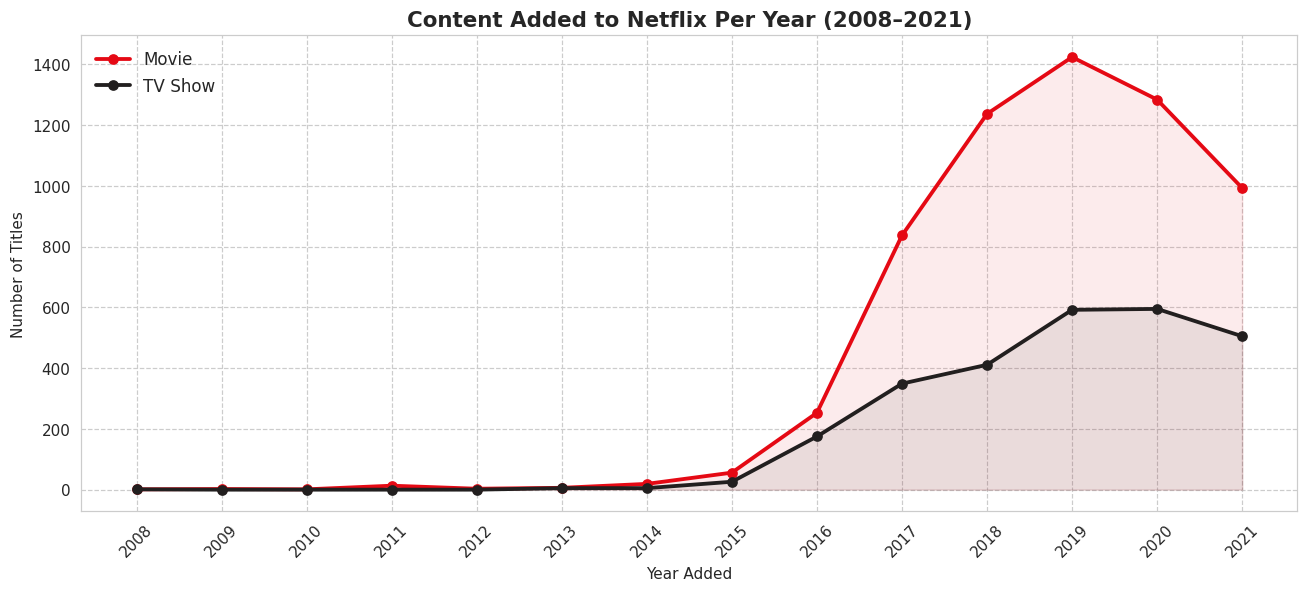

In [9]:
yearly = df_clean[df_clean["year_added"] <= 2021].groupby(["year_added", "type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(yearly.index, yearly["Movie"], marker='o', linewidth=2.5, color=NETFLIX_RED, label="Movie")
ax.plot(yearly.index, yearly["TV Show"], marker='o', linewidth=2.5, color=NETFLIX_DARK, label="TV Show")
ax.fill_between(yearly.index, yearly["Movie"], alpha=0.08, color=NETFLIX_RED)
ax.fill_between(yearly.index, yearly["TV Show"], alpha=0.08, color=NETFLIX_DARK)

ax.set_title("Content Added to Netflix Per Year (2008–2021)", fontsize=14, fontweight='bold')
ax.set_xlabel("Year Added")
ax.set_ylabel("Number of Titles")
ax.legend(frameon=False, fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figs/02_yearly_growth.png", dpi=130, bbox_inches='tight')
plt.show()

> **Insight:** Content additions grew rapidly from 2015 and peaked around 2019, before slightly declining in 2020–2021 — plausibly tied to production slowdowns during the COVID-19 pandemic.

### 6.3 Top Content-Producing Countries

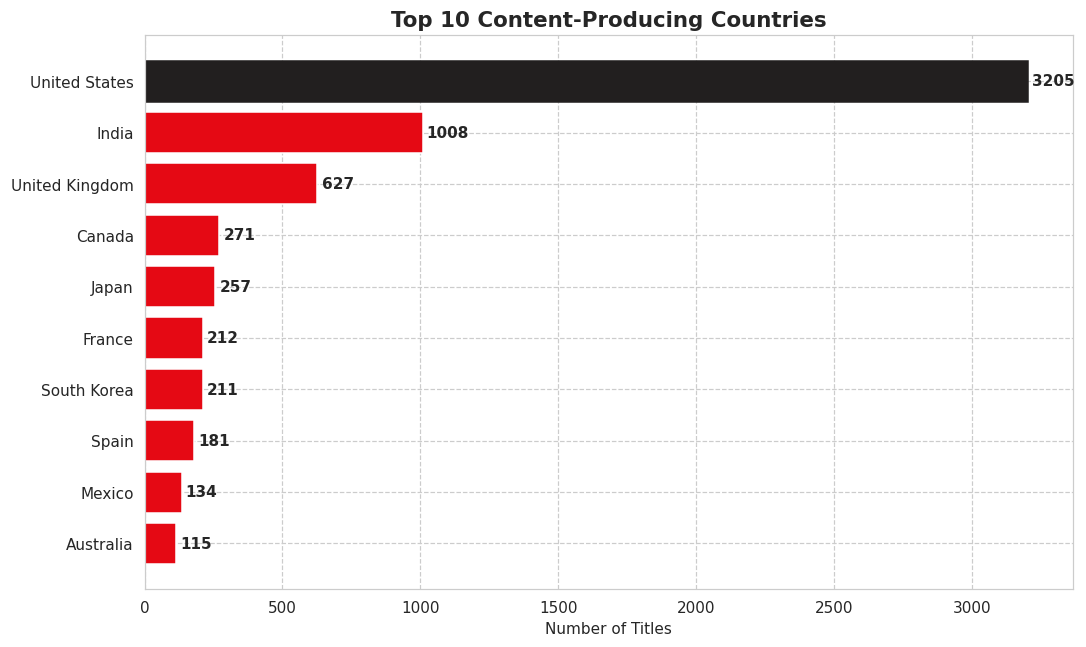

In [10]:
top_countries = df_clean[df_clean["primary_country"] != "Unknown"]["primary_country"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=NETFLIX_RED)
bars[-1].set_color(NETFLIX_DARK)

for i, v in enumerate(top_countries.values[::-1]):
    ax.text(v + 15, i, str(v), va='center', fontweight='bold', fontsize=10)

ax.set_title("Top 10 Content-Producing Countries", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Titles")
plt.tight_layout()
plt.savefig("figs/03_top_countries.png", dpi=130, bbox_inches='tight')
plt.show()

> **Insight:** The United States dominates the catalog by a wide margin, followed by India and the United Kingdom — reflecting both Netflix's origins and its major international content hubs.

### 6.4 Most Common Genres

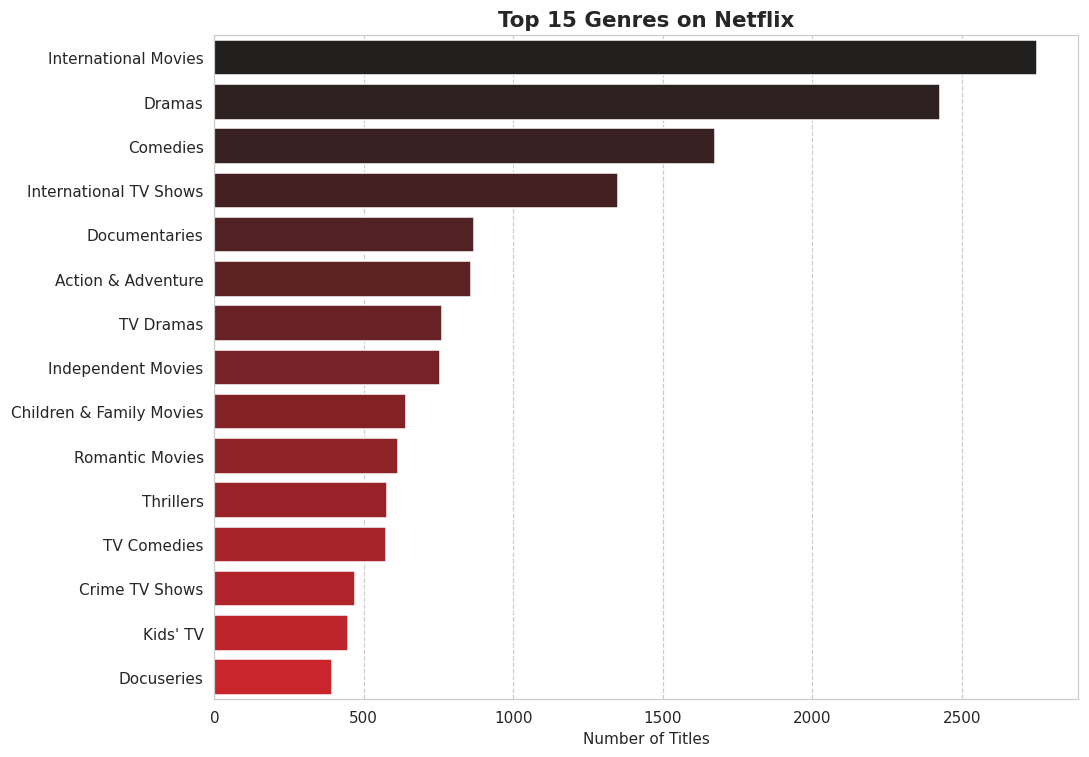

In [11]:
all_genres = Counter([g for genres in df_clean["genre_list"] for g in genres])
top_genres = pd.Series(dict(all_genres)).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette([NETFLIX_RED, NETFLIX_DARK], n_colors=len(top_genres))
sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax,
            palette=sns.blend_palette([NETFLIX_DARK, NETFLIX_RED], n_colors=len(top_genres)))
ax.set_title("Top 15 Genres on Netflix", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figs/04_top_genres.png", dpi=130, bbox_inches='tight')
plt.show()

> **Insight:** International Movies, Dramas, and Comedies are the most represented genres, showing Netflix's dual focus on broad global appeal and mainstream storytelling.

### 6.5 Content Rating Distribution

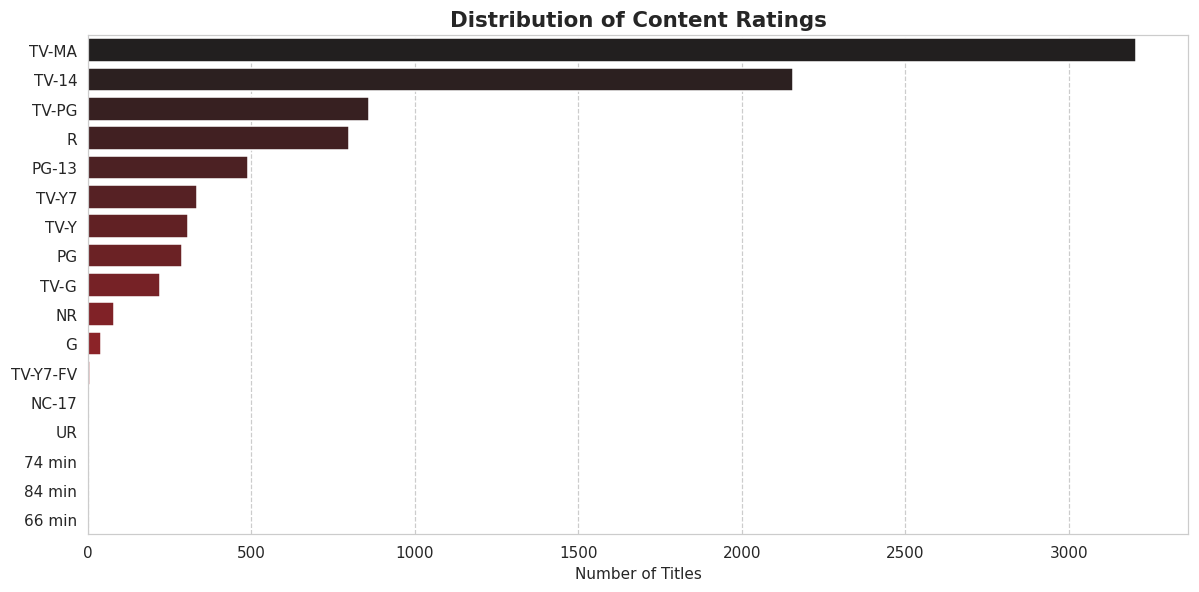

In [12]:
rating_order = df_clean["rating"].value_counts().index

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.countplot(data=df_clean, y="rating", order=rating_order, ax=ax,
              palette=sns.blend_palette([NETFLIX_DARK, NETFLIX_RED], n_colors=len(rating_order)))
ax.set_title("Distribution of Content Ratings", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figs/05_ratings.png", dpi=130, bbox_inches='tight')
plt.show()

> **Insight:** TV-MA and TV-14 are the most common ratings — the catalog skews toward mature/teen audiences rather than young children.

### 6.6 Release Year Distribution

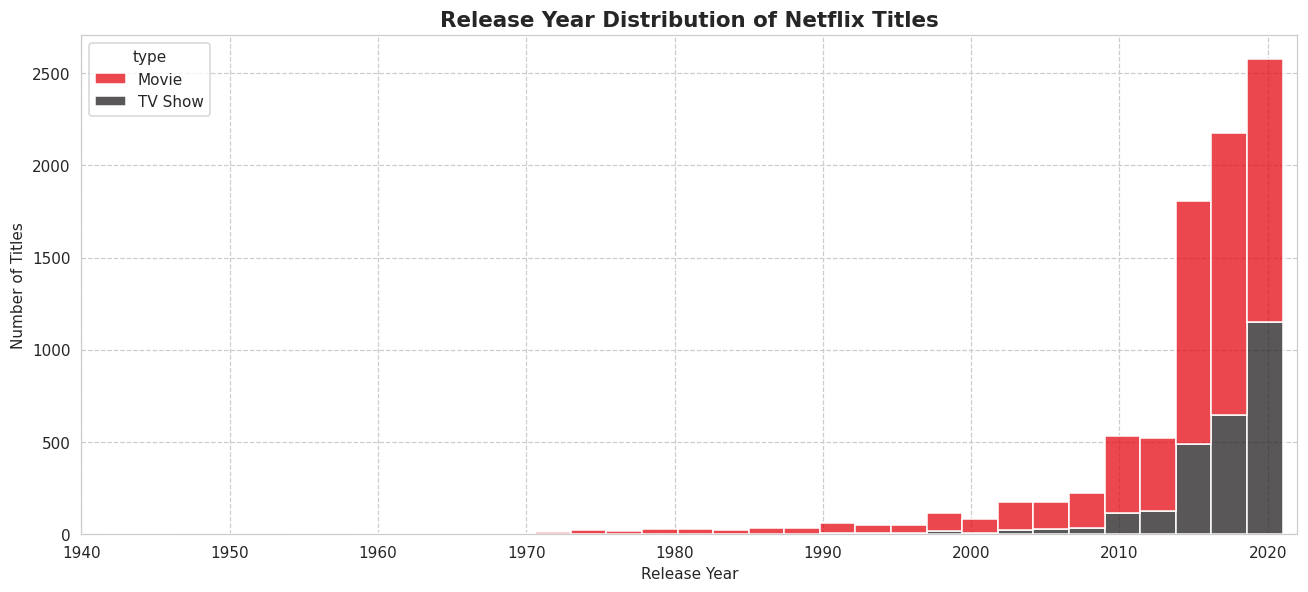

In [13]:
fig, ax = plt.subplots(figsize=(12, 5.5))
sns.histplot(data=df_clean, x="release_year", hue="type", multiple="stack",
             bins=40, palette=[NETFLIX_RED, NETFLIX_DARK], ax=ax, edgecolor='white')
ax.set_title("Release Year Distribution of Netflix Titles", fontsize=14, fontweight='bold')
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Titles")
ax.set_xlim(1940, 2022)
plt.tight_layout()
plt.savefig("figs/06_release_year_dist.png", dpi=130, bbox_inches='tight')
plt.show()

> **Insight:** The vast majority of titles were released after 2010, confirming Netflix's catalog is weighted toward recent content rather than classic film/TV libraries.

### 6.7 Movie Duration Distribution

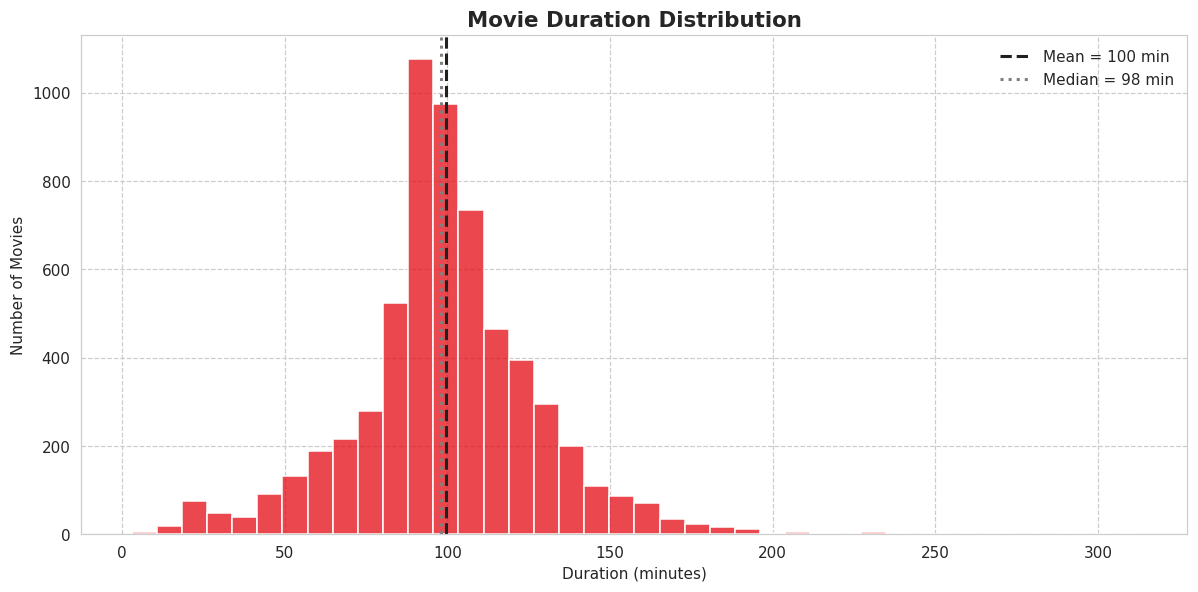

In [14]:
movie_durations = df_clean[df_clean["type"] == "Movie"]["duration_int"].dropna()

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.histplot(movie_durations, bins=40, color=NETFLIX_RED, ax=ax, edgecolor='white')
ax.axvline(movie_durations.mean(), color=NETFLIX_DARK, linestyle='--', linewidth=2,
           label=f"Mean = {movie_durations.mean():.0f} min")
ax.axvline(movie_durations.median(), color='gray', linestyle=':', linewidth=2,
           label=f"Median = {movie_durations.median():.0f} min")
ax.set_title("Movie Duration Distribution", fontsize=14, fontweight='bold')
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Number of Movies")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("figs/07_movie_duration.png", dpi=130, bbox_inches='tight')
plt.show()

> **Insight:** Most movies cluster between 80–120 minutes, in line with typical theatrical runtimes, with a mean around 100 minutes.

### 6.8 TV Show Seasons

67.2% of TV shows on Netflix have only a single season


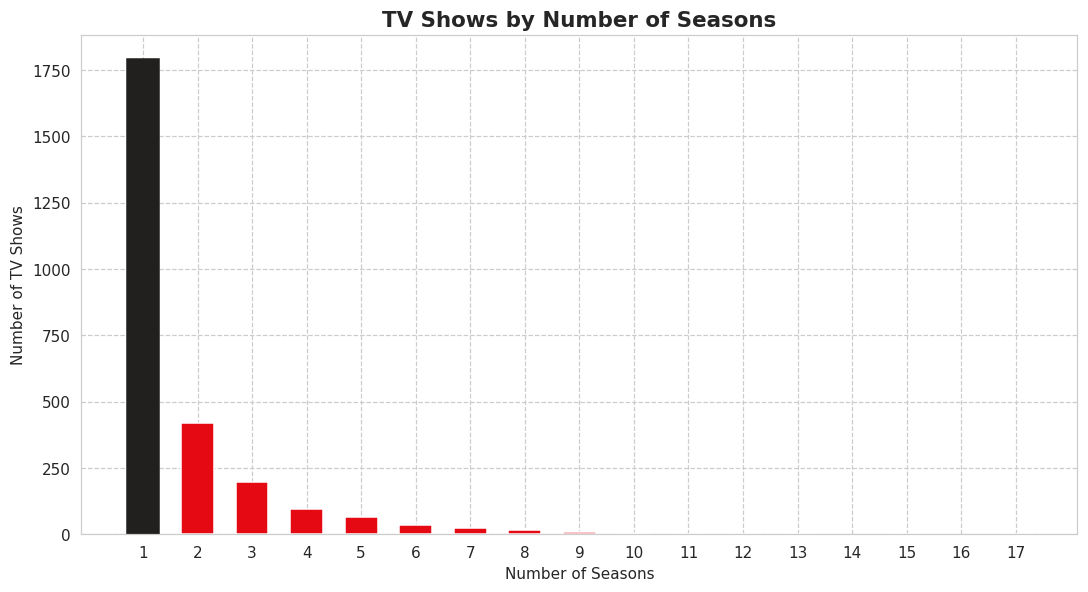

In [15]:
season_counts = df_clean[df_clean["type"] == "TV Show"]["duration_int"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(season_counts.index.astype(int), season_counts.values, color=NETFLIX_RED, width=0.6)
bars[0].set_color(NETFLIX_DARK)
ax.set_title("TV Shows by Number of Seasons", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Seasons")
ax.set_ylabel("Number of TV Shows")
ax.set_xticks(range(1, int(season_counts.index.max()) + 1))
plt.tight_layout()
plt.savefig("figs/08_tv_seasons.png", dpi=130, bbox_inches='tight')
plt.show()

pct_single_season = (season_counts.loc[1] / season_counts.sum() * 100)
print(f"{pct_single_season:.1f}% of TV shows on Netflix have only a single season")

> **Insight:** The vast majority of TV shows on Netflix have only a single season, suggesting Netflix hosts many limited series/licensed shows rather than long-running originals.

### 6.9 Seasonality: When Does Netflix Add Content?

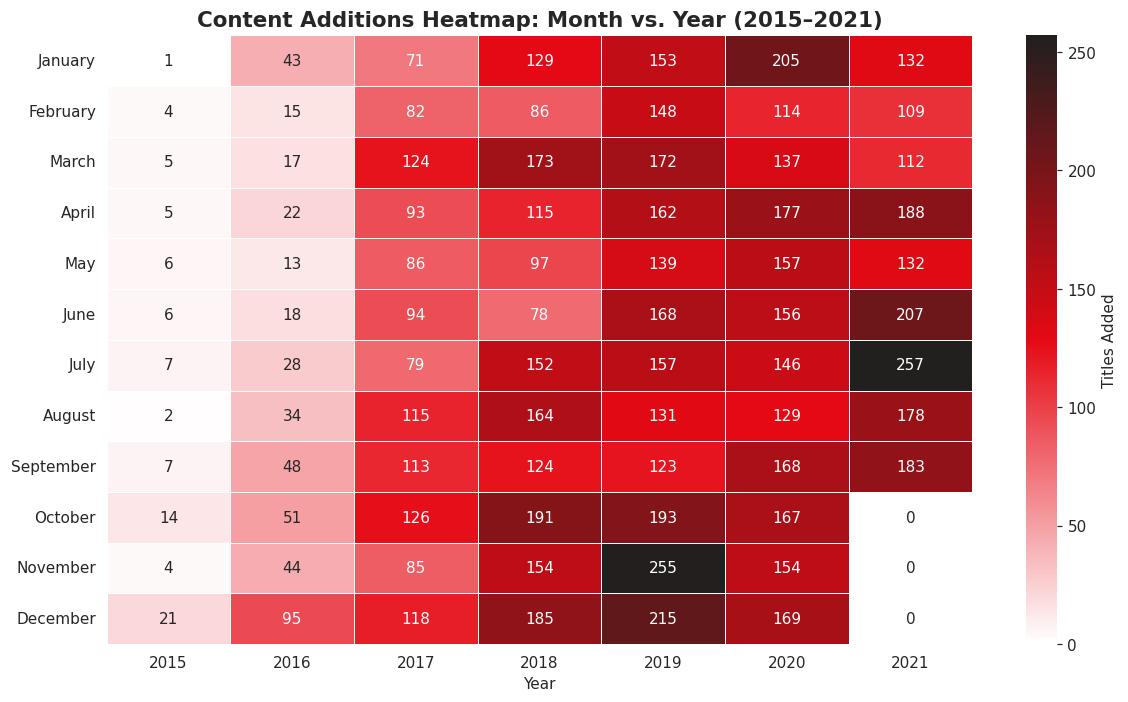

In [16]:
month_order = ["January","February","March","April","May","June","July",
               "August","September","October","November","December"]
heatmap_data = df_clean[(df_clean["year_added"] >= 2015) & (df_clean["year_added"] <= 2021)]
heat_pivot = heatmap_data.groupby(["month_added", "year_added"]).size().unstack(fill_value=0)
heat_pivot = heat_pivot.reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(heat_pivot, cmap=sns.blend_palette(["#FFFFFF", NETFLIX_RED, NETFLIX_DARK], as_cmap=True),
            annot=True, fmt='d', linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'label': 'Titles Added'})
ax.set_title("Content Additions Heatmap: Month vs. Year (2015–2021)", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figs/09_heatmap_month_year.png", dpi=130, bbox_inches='tight')
plt.show()

> **Insight:** Content additions are fairly consistent month-to-month with a slight uptick toward the end of the year (October–December), likely tied to holiday-season releases.

### 6.10 Most Prolific Directors

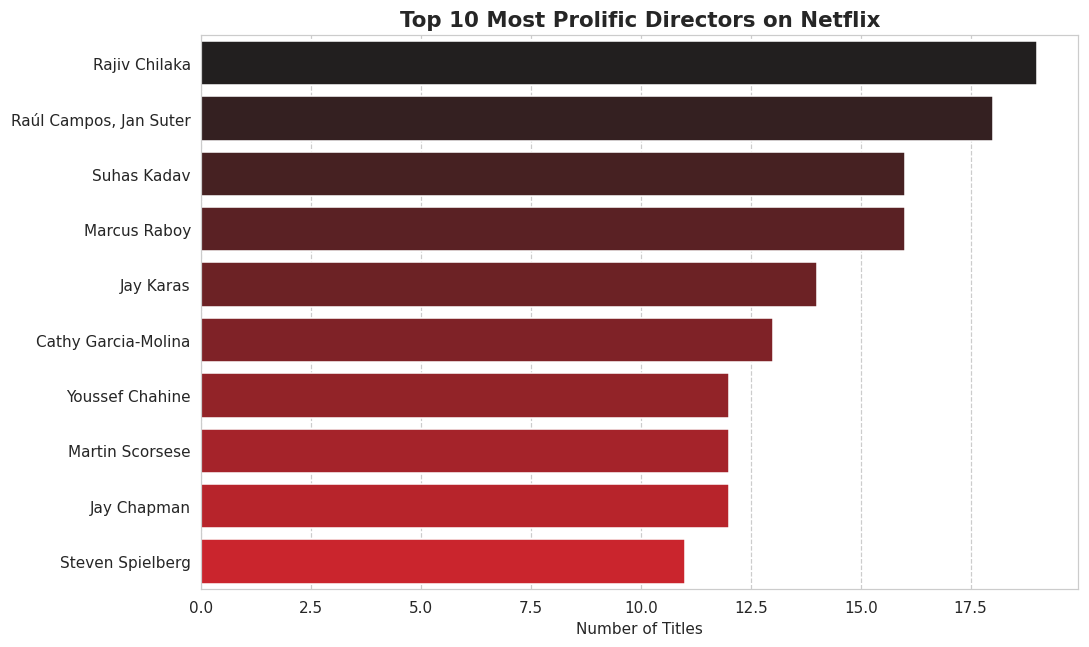

In [17]:
top_directors = df_clean[df_clean["director"] != "Unknown"]["director"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_directors.values, y=top_directors.index, ax=ax,
            palette=sns.blend_palette([NETFLIX_DARK, NETFLIX_RED], n_colors=len(top_directors)))
ax.set_title("Top 10 Most Prolific Directors on Netflix", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figs/10_top_directors.png", dpi=130, bbox_inches='tight')
plt.show()

> **Insight:** Directors like Rajiv Chilaka (children's animation) and Jan Suter / Raúl Campos (stand-up comedy specials) appear most frequently, reflecting Netflix's investment in franchised kids' content and comedy specials.

---
## 7. Summary of Key Findings

In [18]:
summary = {
    "Total titles analyzed": len(df_clean),
    "Movies": int((df_clean['type']=='Movie').sum()),
    "TV Shows": int((df_clean['type']=='TV Show').sum()),
    "Countries represented": df_clean.loc[df_clean['primary_country']!='Unknown','primary_country'].nunique(),
    "Unique genres": len(all_genres),
    "Most common rating": df_clean['rating'].mode()[0],
    "Peak content-addition year": int(yearly.sum(axis=1).idxmax()),
    "Average movie duration (min)": round(movie_durations.mean(), 1),
}
for k, v in summary.items():
    print(f"{k:32s}: {v}")

Total titles analyzed           : 8793
Movies                          : 6129
TV Shows                        : 2664
Countries represented           : 86
Unique genres                   : 42
Most common rating              : TV-MA
Peak content-addition year      : 2019
Average movie duration (min)    : 99.6


## 8. Conclusions

- **Movies outnumber TV Shows** roughly 7:3 across the catalog.
- **Content additions accelerated sharply from 2015–2019**, then cooled slightly during the pandemic years.
- **The U.S., India, and the U.K.** are the top three content-producing countries.
- **International Movies, Dramas, and Comedies** are the most common genres.
- **TV-MA and TV-14** dominate the rating distribution — this is a mature-skewing catalog.
- **Most titles are recent** (post-2010), and **most TV shows run for only one season**.
- Content additions show **mild seasonality**, increasing toward year-end.

### Possible Next Steps
- Build an interactive dashboard (Tableau / Power BI / Plotly Dash) on top of `netflix_titles_cleaned.csv`.
- Apply NLP/topic modeling to the `description` column to cluster titles thematically.
- Combine with IMDb/Rotten Tomatoes ratings to study content type vs. audience reception.

---
*Dataset source: [Netflix Movies and TV Shows — Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows)*